### Enable importing modules from the parent project directory
 --> (e.g., for running this script from subfolders like /scripts or /notebooks)

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

### Importing necessary libraries

In [2]:
import pandas as pd  # Data manipulation and DataFrame support
import numpy as np  # Numerical computing with arrays
import math  # Basic mathematical functions
import matplotlib.pyplot as plt  # Plotting and visualization
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Evaluation metrics
from statistics import mode  # Compute statistical mode
import folium  # Interactive maps (leaflet.js-based)
from folium.plugins import MarkerCluster  # Cluster markers on maps
from scipy.stats import pearsonr  # Pearson correlation calculation
from sklearn.preprocessing import StandardScaler  # Z-score normalization
from sklearn.preprocessing import MinMaxScaler  # Scale features to 0–1 range
from tqdm import tqdm  # Progress bars for loops
from prophet import Prophet  # Facebook Prophet time series forecasting
import random  # Random number generation
from sklearn.impute import SimpleImputer  # Basic missing value imputation
from typing import Dict  # Type hinting for dictionaries
import seaborn as sns  # Statistical data visualization
from sklearn.impute import SimpleImputer  # (Duplicate) Basic imputation again
from IPython.display import display, HTML  # Pretty HTML display in notebooks
from sklearn.decomposition import PCA  # Principal Component Analysis (dimensionality reduction)
from sklearn.preprocessing import StandardScaler  # (Duplicate) Z-score scaling
from statsmodels.tsa.holtwinters import ExponentialSmoothing  # Time series smoothing & forecasting
from sklearn.ensemble import RandomForestRegressor  # Random Forest for regression tasks
from sklearn.inspection import permutation_importance  # Feature importance via permutation
import warnings  # Control warning messages
warnings.filterwarnings("ignore")  # Suppress warnings (useful in notebooks)
from prophet.plot import plot_plotly, plot_components_plotly  # Plotting Prophet results
from prophet.diagnostics import cross_validation, performance_metrics  # Prophet diagnostics tools

In [3]:
from typing import List, Tuple  # Type hinting for lists and tuples

from Algorithms.CDREC import CDRec  # Collaborative Denoising for matrix completion
from Algorithms.TKCM import TKCM  # Top-k Case Matching (basic version)
from Algorithms.TKCM_Weighted import TKCM_Weighted  # TKCM with similarity-based weighting
from Algorithms.DynaMMO import DynaMMo  # Dynamic Matrix Modeling for time series imputation
from Algorithms.SoftImpute import SoftImpute  # Low-rank matrix completion using soft-thresholding
from Algorithms.SVDImpute import IterativeSVD  # Iterative SVD-based matrix imputation
from Algorithms.trmf import TRMFImputer  # Temporal Regularized Matrix Factorization
from Algorithms.ST_MVL import ST_MVL  # Space-Time Matrix-Vector Learning
from Algorithms.TKCM_PLUS import TKCM_PLUS  # TKCM variant with alpha–beta blending, also using Target series known values to fill the missing values
from Algorithms.TKCM_PRO import TKCM_PRO  # Pro version of TKCM with anchor filtering, here averaging the refrence to fill the missing values


### Loading the Dataset

In [4]:

valley_df = pd.read_csv("D:\\Thesis\\Project\\Data\\valley_data.csv")

# Counting the different types of missingness in the dataset
stats = {
    "Total Rows": len(valley_df),
    "Total Columns": len(valley_df.columns),
    "Zero Values": (valley_df == 0).sum().sum(),
    "NaN Values": valley_df.isna().sum().sum(),
    "Blank Strings": (valley_df == "").sum().sum(),
    "Unknown Strings": (valley_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,7079427
1,Total Columns,6
2,Zero Values,1667902
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


#### Displaying the first 5 rows of the data

In [5]:
valley_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,37100MS,LT,Temperatura dell´aria,°C,2025-01-01 00:00:00,-10.4
1,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 23:30:00,-8.9
2,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 23:00:00,-9.5
3,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 22:30:00,-8.1
4,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 22:00:00,-8.8


### Displaying column-wise metadata

##### Includes:
- Total number of entries
- Column names and types
- Non-null counts
- Memory usage

In [6]:
valley_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079427 entries, 0 to 7079426
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 324.1+ MB


### describe() provide us with statistical summary of numeric columns
#### Includes:
- Count, mean, std deviation
- Min, 25%, 50%, 75%, and max values

In [7]:
valley_df.describe()

,value
count,7.079427e+06
mean,1.722966e+02
std,3.336668e+02
min,-9.760000e+01
25%,0.000000e+00
50%,3.600000e+00
75%,1.000000e+02
max,1.474800e+03


In [8]:
# Preview data
print("🔍 Shape:", valley_df.shape)

🔍 Shape: (7079427, 6)


In [9]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", valley_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


### Checking all the unique sensor codes i have in this dataset

In [10]:
unique_values = valley_df['sensor_code'].unique()
unique_values

array(['LT', 'N', 'WR', 'WG', 'WG.BOE', 'LF', 'LD.RED', 'GS', 'SD', 'HS',
       'W', 'WT'], dtype=object)

### checking unique similar station_codes

In [11]:
unique_values1 = valley_df['station_code'].unique()
unique_values1

array(['37100MS', '20500MS', '19300MS', '80300MS', '50500MS', '34500MS',
       '56900MS', '54500MS', '69900MS', '09700MS', '82200MS', '88820MS',
       '59700MS', '85120MS', '83200MS', '86900MS', '39100MS', '08200MS',
       '23200MS', '47400MS', '86600MS', '37700MS', '74900MS', '89190MS',
       '22210MS', '25900MS', '73500MS', '68600MS', '02200MS', '03100MS',
       '41000MS', '75600MS', '62600MS', '74200MS', '11400MS', '02500MS',
       '33500MS', '44500MS', '06400MS', '65600MS', '24400MS', '43200MS',
       '78305MS', '56500MS', '42700MS', '15800MS', '65350MS', '89950SE',
       '02250SE', '78150SE', '82910MS', '47150SE', '27100MS', '89155SE',
       '89355SE', '85700MS', '89055SE', '42150SE', '39050SE', '79450SE',
       '87300MS', '66500MS', '20910MS', '31410MS', '78110MS', '61300MS',
       '01110MS', '71510MS', '79300MS', '75510SE', '90150SE', '91510MS'],
      dtype=object)

### Looking at the descriptions of the sensor what is meaning of those sensor codes

In [12]:
unique_values2 = valley_df['description_it'].unique()
unique_values2

array(['Temperatura dell´aria', 'Precipitazioni', 'Direzione del vento',
       'Velocità del vento', 'Velocitá raffica', 'Umidità relativa',
       'Pressione atmosferica', 'Radiazione globale ',
       'Durata soleggiamento', 'Altezza neve al suolo',
       'Livello idrometrico', 'Temperatura acqua'], dtype=object)

### checking unit of data values

In [13]:
unique_values3 = valley_df['unit'].unique()
unique_values3

array(['°C', 'mm', '° ', 'm/s', '%', 'hPa', 'W/m²', 's', 'cm'],
      dtype=object)

### looking at unique values

In [14]:
unique_values4 = valley_df['value'].unique()
unique_values4

array([-10.4,  -8.9,  -9.5, ..., 981.9, 855.3, 802.7], shape=(11245,))

### Checking the columns i have and how they pronounced

In [15]:
column_names = list(valley_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

### counting the zeroes and sum them 

In [16]:
zero_counts = (valley_df == 0).sum()
print(zero_counts)

station_code            0
sensor_code             0
description_it          0
unit                    0
timestamp               0
value             1667902
dtype: int64


### displaying the values with zeroes

In [17]:
valley_df[valley_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
116,37100MS,LT,Temperatura dell´aria,°C,2024-12-29 14:00:00,0.0
338,37100MS,LT,Temperatura dell´aria,°C,2024-12-24 23:00:00,0.0
426,37100MS,LT,Temperatura dell´aria,°C,2024-12-23 03:00:00,0.0
598,37100MS,LT,Temperatura dell´aria,°C,2024-12-19 13:00:00,0.0
637,37100MS,LT,Temperatura dell´aria,°C,2024-12-18 17:30:00,0.0


#### checking if values are numeric, if yes then add percentage to the zeroes and sort them by percentage of zero they contain. 

In [18]:
# Make sure 'value' is numeric
valley_df['value'] = pd.to_numeric(valley_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    valley_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


   sensor_code  total_entries  zero_count  zero_percentage
0            N         585918      565938        96.589967
1           SD         773271      643102        83.166445
2           GS         758400      438331        57.796809
3            W          83263        5222         6.271693
4           LT         889920        7619         0.856144
5           WG         713371        4772         0.668937
6           HS          29182         170         0.582551
7       WG.BOE         713371        2423         0.339655
8           WT          83262          60         0.072062
9           WR         713371         265         0.037148
10          LF         875328           0         0.000000
11      LD.RED         860770           0         0.000000


In [19]:
# Step 1: Select sensor `LF`
lf_df = valley_df[valley_df['sensor_code'] == 'LF'].copy()

In [20]:
# Step 2: Replace `0.0` values with NaN
lf_df.loc[lf_df['value'] == 0.0, 'value'] = np.nan

In [21]:
# Step 3: Pivot to wide format (timestamp × station_code)
lf_df['timestamp'] = pd.to_datetime(lf_df['timestamp'])
pivot_df = lf_df.pivot(index='timestamp', columns='station_code', values='value')

In [22]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [23]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

#### Displaying the clean dataframe to check what i have with me.

In [24]:
clean_df

station_code,01110MS,02200MS,02500MS,03100MS,06400MS,08200MS,09700MS,11400MS,15800MS,19300MS,...,82910MS,83200MS,85120MS,85700MS,86600MS,86900MS,87300MS,88820MS,89190MS,91510MS
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,99.1,90.4,82.5,86.2,94.8,99.8,92.7,91.6,91.9,90.6,...,93.8,87.7,99.9,96.8,95.8,98.1,97.6,83.5,84.3,99.9
2023-01-01 00:30:00,98.1,90.8,80.8,84.9,97.1,99.8,91.1,92.1,92.7,91.7,...,91.8,87.0,99.9,97.7,94.5,97.0,97.5,82.7,84.3,99.9
2023-01-01 01:00:00,98.0,91.5,81.9,83.5,96.7,99.8,90.0,89.1,92.4,90.1,...,92.1,85.3,99.9,97.1,93.5,98.5,99.7,89.8,81.3,99.9
2023-01-01 01:30:00,99.7,92.6,81.1,85.3,97.7,99.8,89.4,88.5,93.3,89.2,...,95.1,84.2,99.9,98.8,92.5,99.2,96.4,90.6,83.9,99.9
2023-01-01 02:00:00,99.8,94.2,81.9,84.5,95.4,99.8,88.2,86.2,94.2,89.1,...,98.6,88.4,99.9,99.6,94.5,99.0,99.9,90.0,80.9,99.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,54.5,74.4,38.3,53.7,48.4,91.3,64.9,51.1,49.7,89.4,...,84.0,90.2,47.1,100.2,99.6,98.7,53.8,95.8,64.1,96.9
2024-12-31 22:30:00,54.7,75.9,41.8,56.0,46.0,91.3,67.3,51.9,50.2,90.5,...,84.5,88.9,48.7,100.2,99.1,100.0,54.0,99.0,61.4,96.0
2024-12-31 23:00:00,54.7,77.3,39.0,55.8,46.4,92.2,64.2,51.1,51.0,90.4,...,85.7,89.0,48.4,99.7,99.7,100.0,57.7,96.6,63.5,96.1


In [25]:
# Step 6: Pick a target station 
target_station = clean_df.columns[2]

#### displaying target station

In [26]:
target_station

'02500MS'

In [27]:
# Step 7: Computing Pearson correlations 
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

### displaying correlations

In [28]:
correlations

station_code
15800MS    0.860133
03100MS    0.856343
06400MS    0.820458
20910MS    0.815276
24400MS    0.812125
71510MS    0.806599
68600MS    0.800845
01110MS    0.791615
20500MS    0.790726
11400MS    0.787193
65600MS    0.757288
02200MS    0.756943
87300MS    0.755742
85120MS    0.755661
78110MS    0.751061
79300MS    0.736962
34500MS    0.730753
75600MS    0.725095
74200MS    0.723658
73500MS    0.720382
66500MS    0.720341
25900MS    0.701794
89190MS    0.688170
82200MS    0.681692
44500MS    0.661228
47400MS    0.660803
78305MS    0.656539
82910MS    0.645984
69900MS    0.640392
50500MS    0.635309
09700MS    0.633138
54500MS    0.627258
61300MS    0.615036
80300MS    0.614604
37700MS    0.610875
08200MS    0.609098
22210MS    0.560592
31410MS    0.544317
42700MS    0.535828
37100MS    0.530221
83200MS    0.519141
62600MS    0.510519
74900MS    0.487708
19300MS    0.482003
23200MS    0.477953
39100MS    0.473874
88820MS    0.465987
86900MS    0.454714
41000MS    0.453751
56500MS

In [29]:

# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [30]:
top_refs

['15800MS', '03100MS']

#### Checking the final dataframe

In [31]:
final_df

station_code,02500MS,15800MS,03100MS
timestamp,,,
2023-01-01 00:00:00,82.5,91.9,86.2
2023-01-01 00:30:00,80.8,92.7,84.9
2023-01-01 01:00:00,81.9,92.4,83.5
2023-01-01 01:30:00,81.1,93.3,85.3
2023-01-01 02:00:00,81.9,94.2,84.5
...,...,...,...
2024-12-31 22:00:00,38.3,49.7,53.7
2024-12-31 22:30:00,41.8,50.2,56.0
2024-12-31 23:00:00,39.0,51.0,55.8


In [32]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [33]:
pattern_df

station_code,02500MS,15800MS,03100MS,06400MS
timestamp,,,,
2023-01-01 00:00:00,82.5,91.9,86.2,94.8
2023-01-01 00:30:00,80.8,92.7,84.9,97.1
2023-01-01 01:00:00,81.9,92.4,83.5,96.7
2023-01-01 01:30:00,81.1,93.3,85.3,97.7
2023-01-01 02:00:00,81.9,94.2,84.5,95.4
...,...,...,...,...
2024-12-31 22:00:00,38.3,49.7,53.7,48.4
2024-12-31 22:30:00,41.8,50.2,56.0,46.0
2024-12-31 23:00:00,39.0,51.0,55.8,46.4


#### Plotting target station with reference stations

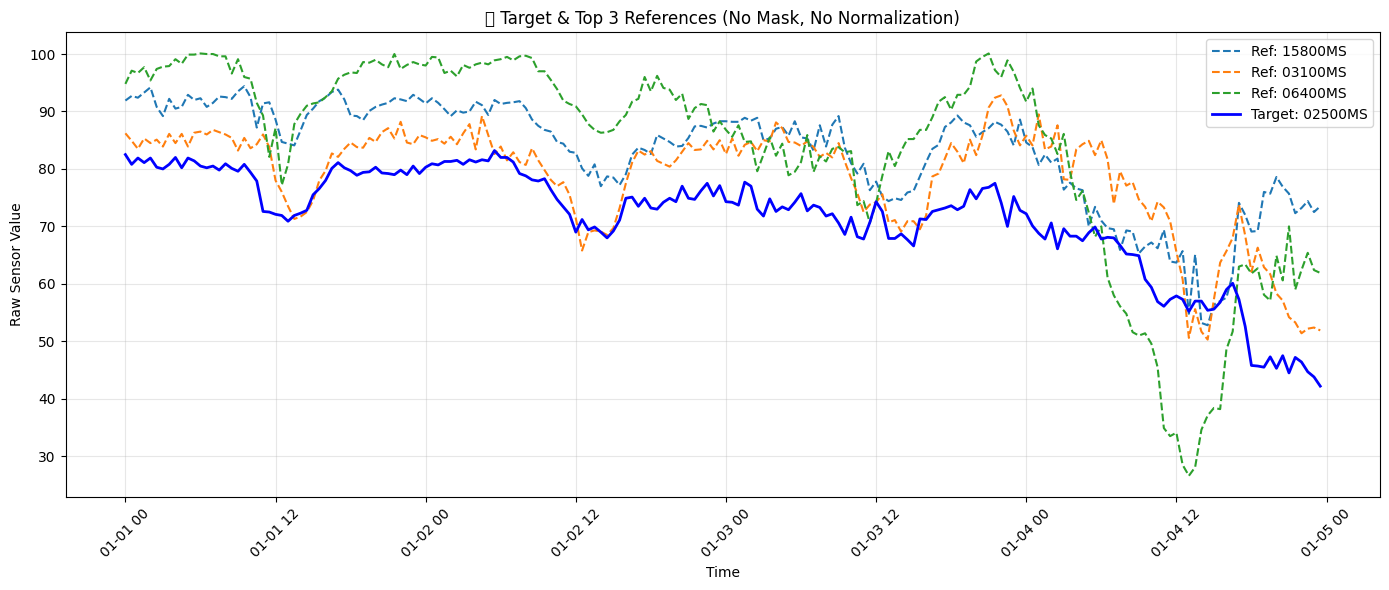

In [34]:
# Define the stations 
target = "02500MS"
references = ["15800MS","03100MS","06400MS"]

# Defining time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slicing the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plotting the reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plotting the target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------------------
# 🔹 STEP 1: Normalizing the Time Series Data
# -------------------------------------------

In [35]:
from sklearn.preprocessing import StandardScaler

#  Initialize the Scaler
scaler = StandardScaler()

#  Fitting the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

#  Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

#  Print shape and preview
print(" Normalized shape:", normalized_df.shape)
display(normalized_df.head())


 Normalized shape: (14593, 4)


station_code,02500MS,15800MS,03100MS,06400MS
timestamp,,,,
2023-01-01 00:00:00,1.119923,1.189939,0.666856,1.250501
2023-01-01 00:30:00,1.038581,1.225965,0.609234,1.356561
2023-01-01 01:00:00,1.091214,1.212455,0.547179,1.338115
2023-01-01 01:30:00,1.052935,1.252984,0.626964,1.384229
2023-01-01 02:00:00,1.091214,1.293513,0.591504,1.278168


-> What This Does:
- Performs z-score normalization: subtracts the mean, divides by standard deviation
- Ensures each sensor has mean 0 and std 1
- Prevents scale bias in distance-based algorithms such as TKCM, CDRec, ST_MVL
- here, we can use normalized_df[target_station] for masking, and all columns for reference

STEP 2: Inject Block-Missing Values in the Middle of the Target Series
I’ll define a function that injects a block of NaNs in the middle of the target time series (from normalized_df[target_station]), and 
This will keep track of:
- The masked series
- The block’s start and end index
- The corresponding true values for evaluation

# ---------------------------------------------------------
# 🔹 STEP 2: Defining function to the inject block-missing in the middle
# ---------------------------------------------------------

In [36]:
def introduce_block_missing_middle(series: pd.Series, block_length: int) -> Tuple[pd.Series, int, int]:
    """
    Introduce a block of NaN values into the middle of a time series.

    Parameters:
        series (pd.Series): The original time series (normalized)
        block_length (int): The number of consecutive values to mask

    Returns:
        masked_series (pd.Series): The modified series with NaNs
        start_idx (int): Starting index of the missing block
        end_idx (int): Ending index (exclusive) of the missing block
    """
    ts = series.copy()
    mid_start = len(ts) // 2 - block_length // 2
    mid_end = mid_start + block_length
    ts[mid_start:mid_end] = np.nan
    return ts, mid_start, mid_end


# ---------------------------------------------------------
# 🔹 STEP 2b: Applying block-missing to the normalized target series
# ---------------------------------------------------------

In [37]:
# Define target station 
target_station = "02500MS"

# Define block length (e.g. 10 time points ~ 5 hours if half-hourly)
block_length = 3131  # for 1 month data

# Apply the masking function
masked_target, start_idx, end_idx = introduce_block_missing_middle(
    normalized_df[target_station],
    block_length
)

# Print info about the block
print(f"🧱 Missing block injected from index {start_idx} to {end_idx - 1}")
print("🕓 Timestamps of missing block:\n", normalized_df.index[start_idx:end_idx])


🧱 Missing block injected from index 5731 to 8861
🕓 Timestamps of missing block:
 DatetimeIndex(['2023-12-03 09:30:00', '2023-12-03 10:00:00',
               '2023-12-03 10:30:00', '2023-12-03 11:00:00',
               '2023-12-03 11:30:00', '2023-12-03 12:00:00',
               '2023-12-03 12:30:00', '2023-12-03 13:00:00',
               '2023-12-03 13:30:00', '2023-12-03 14:00:00',
               ...
               '2024-02-06 10:00:00', '2024-02-06 10:30:00',
               '2024-02-06 11:00:00', '2024-02-06 11:30:00',
               '2024-02-06 12:00:00', '2024-02-06 12:30:00',
               '2024-02-06 13:00:00', '2024-02-06 13:30:00',
               '2024-02-06 14:00:00', '2024-02-06 14:30:00'],
              dtype='datetime64[ns]', name='timestamp', length=3131, freq=None)


📦 STEP 3: Convert to NumPy Arrays & Prepare Evaluation Inputs

-> This includes:

- Masked target series (with middle block removed)
- Reference matrix (fully observed, already normalized)
- True values from the masked block (for MAE/RMSE)
- Indices of the masked values

# ---------------------------------------------------------
# 🔹 STEP 3: Preparing NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

In [38]:
#  Extracting the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

#  Getting reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

#  Getting the masked target series as array (shape: time,)
masked_target_array = masked_target.to_numpy().copy()

#  Getting the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()

#  Saving the index positions of the block-masked values
nan_block_indices = np.arange(start_idx, end_idx)

#  Preview shapes and sanity check
print(" Target shape:", masked_target_array.shape)
print(" Ref matrix shape:", ref_matrix.shape)
print(" Block indices:", nan_block_indices)
print(" Target preview (with NaNs):", masked_target_array[start_idx:end_idx])


 Target shape: (14593,)
 Ref matrix shape: (3, 14593)
 Block indices: [5731 5732 5733 ... 8859 8860 8861]
 Target preview (with NaNs): [nan nan nan ... nan nan nan]


# -----------------------------------------------
# 🔹 STEP 4.1: Setting safe parameters for all models
# -----------------------------------------------

In [39]:
k = 5  # number of top matching sequences (for TKCMs)
l = 4  # sliding window size
rank = max(1, min(ref_matrix.shape[0] - 1, 2))  # safe low-rank dimension for SVD, TRMF


# -----------------------------------------------
# 🔹 STEP 4.2: Applying each model with correct usage
# -----------------------------------------------

In [40]:
# Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])

#  TKCM
tkcm = TKCM(k=k, l=l)
tkcm_imputed = tkcm.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

#  TKCM_Weighted
tkcm_w = TKCM_Weighted(k=k, l=l)
tkcm_weighted_imputed = tkcm_w.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

#  TKCM_PLUS
tkcm_plus = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5)
tkcm_plus_imputed = tkcm_plus.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)


#  TKCM_PRO
tkcm_pro = TKCM_PRO(k=k, l=l)
tkcm_pro_imputed = tkcm_pro.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)


#  CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Only return target row

#  DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

# SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

#  IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

#  ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

# TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]


In [41]:
# In TKCM imputation loop
missing_indices = np.where(np.isnan(masked_target_array))[0]

for offset in missing_indices:
    imputed_series = tkcm.impute(masked_target_array.copy(), offset=offset, ref_ts=ref_matrix)
    print(f"Offset {offset} → Imputed value = {imputed_series[offset]}")


Offset 2140 → Imputed value = -1.492608975643674
Offset 2141 → Imputed value = -1.5835212708512756
Offset 5731 → Imputed value = 0.14285536656465364
Offset 5732 → Imputed value = 0.17252148394818687
Offset 5733 → Imputed value = 0.201230629803219
Offset 5734 → Imputed value = 0.24907920622827237
Offset 5735 → Imputed value = 0.026104840087523184
Offset 5736 → Imputed value = 0.04609459865884796
Offset 5737 → Imputed value = -0.228556230020959
Offset 5738 → Imputed value = -0.11664388294993275
Offset 5739 → Imputed value = -0.3357903629766777
Offset 5740 → Imputed value = -0.108084460957022
Offset 5741 → Imputed value = -0.011270371287617322
Offset 5742 → Imputed value = -0.05624803312716768
Offset 5743 → Imputed value = -0.03710860255714622
Offset 5744 → Imputed value = 0.060502493349962896
Offset 5745 → Imputed value = 0.1733718119494901
Offset 5746 → Imputed value = 0.2059088439185265
Offset 5747 → Imputed value = 0.22510159625214685
Offset 5748 → Imputed value = 0.2509931492852745
O

# ---------------------------------------------------------
# 🔹 STEP 5: Evaluating all imputation methods (Middle Block)
# ---------------------------------------------------------

In [42]:
results_block = []

# True values for the missing block
true_vals = true_target_array[start_idx:end_idx]
missing_indices = np.arange(start_idx, end_idx)

# Helper to evaluate predictions against true values
def evaluate_direct(name, imputed_array):
    try:
        predicted = imputed_array[start_idx:end_idx]
        mae = np.mean(np.abs(predicted - true_vals))
        rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))
        results_block.append({
            "Method": name,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "First Imputed": round(predicted[0], 4),
            "Last Imputed": round(predicted[-1], 4),
            "First True": round(true_vals[0], 4),
            "Last True": round(true_vals[-1], 4),
            "Missing Block": "Middle"
        })
    except Exception as e:
        results_block.append({
            "Method": name,
            "MAE": "NaN",
            "RMSE": "NaN",
            "First Imputed": "NaN",
            "Last Imputed": "NaN",
            "First True": round(true_vals[0], 4),
            "Last True": round(true_vals[-1], 4),
            "Missing Block": "Middle"
        })

# TKCM (loop over all missing indices)
try:
    tkcm_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_imputed = TKCM(k=k, l=l).impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM", tkcm_imputed)
except Exception as e:
    print(" TKCM failed:", e)
    evaluate_direct("TKCM", np.full_like(true_vals, np.nan))

#  TKCM_Weighted (loop over all missing indices)
try:
    tkcm_weighted_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_weighted_imputed = TKCM_Weighted(k=k, l=l).impute(tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM_Weighted", tkcm_weighted_imputed)
except Exception as e:
    print(" TKCM_Weighted failed:", e)
    evaluate_direct("TKCM_Weighted", np.full_like(true_vals, np.nan))
    
#  TKCM_PLUS (loop over all missing indices)
try:
    tkcm_plus_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_plus_imputed = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5).impute(
            tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix
        )
    evaluate_direct("TKCM_PLUS", tkcm_plus_imputed)
except Exception as e:
    print(" TKCM_PLUS failed:", e)
    evaluate_direct("TKCM_PLUS", np.full_like(true_vals, np.nan))

#  TKCM_PRO (loop over all missing indices)
try:
    tkcm_pro_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_pro_imputed = TKCM_PRO(k=k, l=l).impute(
            tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix
        )
    evaluate_direct("TKCM_PRO", tkcm_pro_imputed)
except Exception as e:
    print(" TKCM_PRO failed:", e)
    evaluate_direct("TKCM_PRO", np.full_like(true_vals, np.nan))
    




#  Other models 
evaluate_direct("CDRec", cdrec_imputed)
evaluate_direct("DynaMMo", dynammo_imputed)
evaluate_direct("SoftImpute", soft_imputed)
evaluate_direct("SVDImpute", svd_imputed)

#  ST_MVL — remove NaNs from references
try:
    X_stmv = X_stacked.copy()
    X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])
    st_mvl_model = ST_MVL()
    st_mvl_imputed = st_mvl_model.impute(X_stmv)[0]
    evaluate_direct("ST_MVL", st_mvl_imputed)
except Exception as e:
    print("ST_MVL failed:", e)
    evaluate_direct("ST_MVL", np.full_like(true_vals, np.nan))

# TRMF — fixed implementation
try:
    X_trmf_input = X_stacked.T.copy()
    observed_mask = ~np.isnan(X_stacked.T)
    X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()
    trmf_imputed = X_trmf_output[:, 0]
    evaluate_direct("TRMF", trmf_imputed)
except Exception as e:
    print(" TRMF failed:", e)
    evaluate_direct("TRMF", np.full_like(true_vals, np.nan))

# Final Results Display
results_df = pd.DataFrame(results_block)
display(results_df.style.background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"]))


,Method,MAE,RMSE,First Imputed,Last Imputed,First True,Last True,Missing Block
0,TKCM,0.418400,0.529300,0.142900,-1.074100,-0.076300,-0.913600,Middle
1,TKCM_Weighted,0.422600,0.535000,0.147300,-1.104100,-0.076300,-0.913600,Middle
2,TKCM_PLUS,0.838900,0.985900,0.141900,0.000000,-0.076300,-0.913600,Middle
3,TKCM_PRO,1.609200,1.867700,1.464900,-4.330600,-0.076300,-0.913600,Middle
4,CDRec,0.319500,0.416100,0.585100,-1.433500,-0.076300,-0.913600,Middle
5,DynaMMo,0.319600,0.416500,0.587800,-1.439600,-0.076300,-0.913600,Middle
6,SoftImpute,0.317500,0.412700,0.573600,-1.400900,-0.076300,-0.913600,Middle
7,SVDImpute,0.320200,0.417600,0.591300,-1.448900,-0.076300,-0.913600,Middle
8,ST_MVL,0.447200,0.596800,0.683300,-1.465600,-0.076300,-0.913600,Middle
9,TRMF,0.602500,0.713700,0.192400,-0.462700,-0.076300,-0.913600,Middle


### RMSE Comparison of Imputation Methods

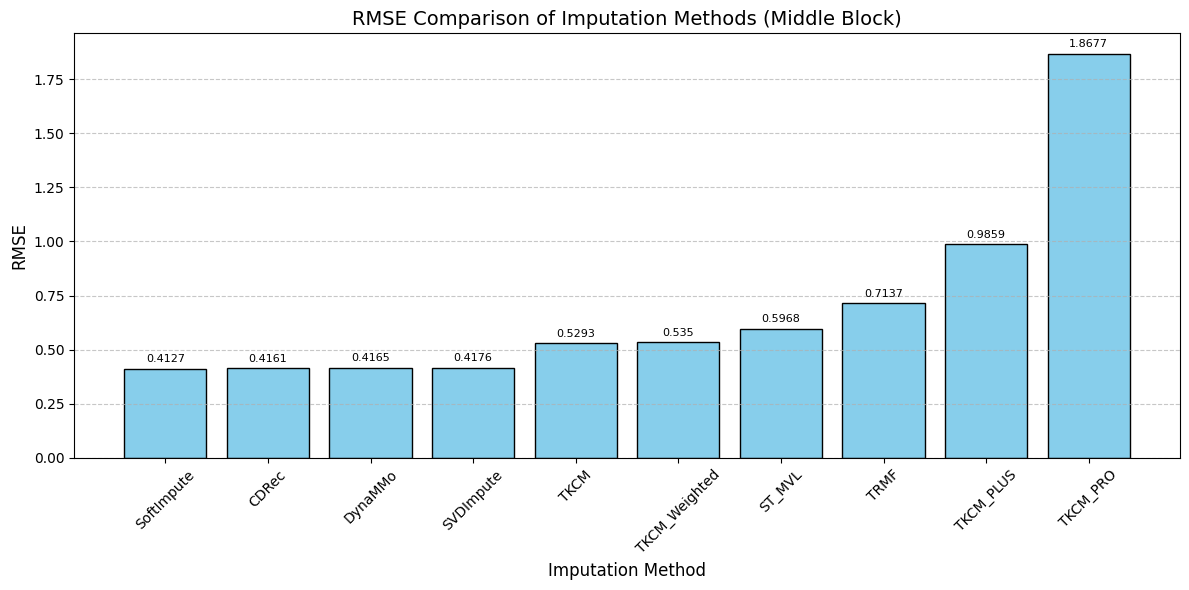

In [43]:
# Sort methods by RMSE ascending for better visual comparison
results_sorted = results_df.sort_values(by="RMSE").reset_index(drop=True)

# Plot settings
fig, ax = plt.subplots(figsize=(12, 6))

# Bar chart
bars = ax.bar(results_sorted["Method"], results_sorted["RMSE"], color="skyblue", edgecolor="black")

# Annotate RMSE values on top of bars
for bar, rmse in zip(bars, results_sorted["RMSE"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{rmse}", 
            ha="center", va="bottom", fontsize=8)

# Labels and title
ax.set_title("RMSE Comparison of Imputation Methods (Middle Block)", fontsize=14)
ax.set_xlabel("Imputation Method", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### MAE Comparison Of Imputation Methods

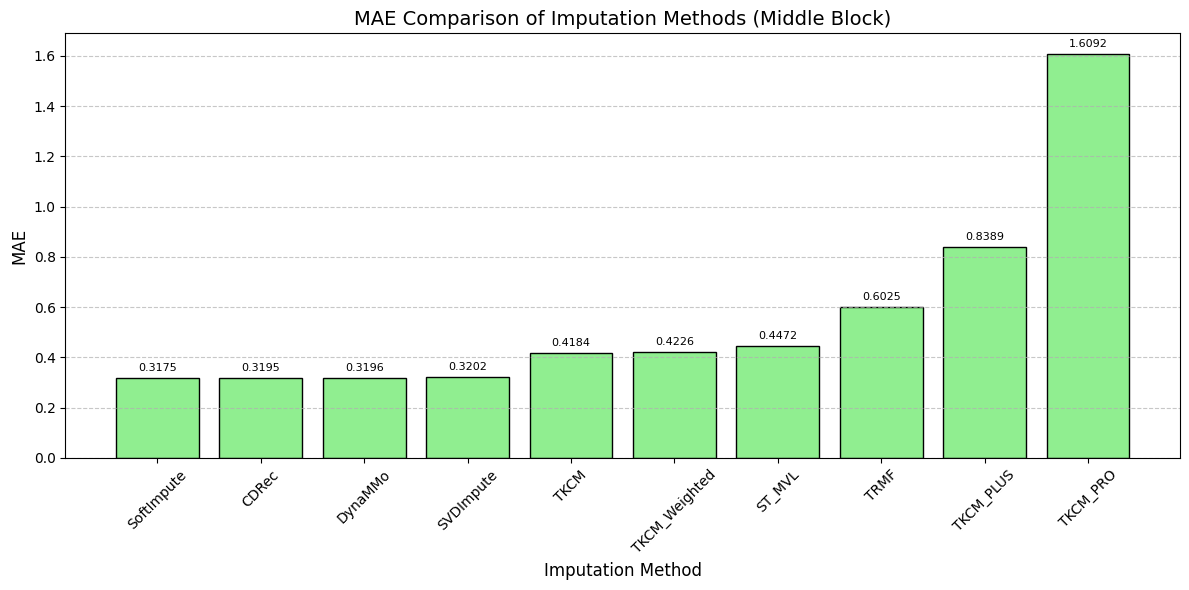

In [44]:
# Sort by MAE
results_sorted_mae = results_df.sort_values(by="MAE").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(results_sorted_mae["Method"], results_sorted_mae["MAE"], color="lightgreen", edgecolor="black")

for bar, mae in zip(bars, results_sorted_mae["MAE"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{mae}", 
            ha="center", va="bottom", fontsize=8)

ax.set_title("MAE Comparison of Imputation Methods (Middle Block)", fontsize=14)
ax.set_xlabel("Imputation Method", fontsize=12)
ax.set_ylabel("MAE", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Line Chart Implementation of all the algorithms

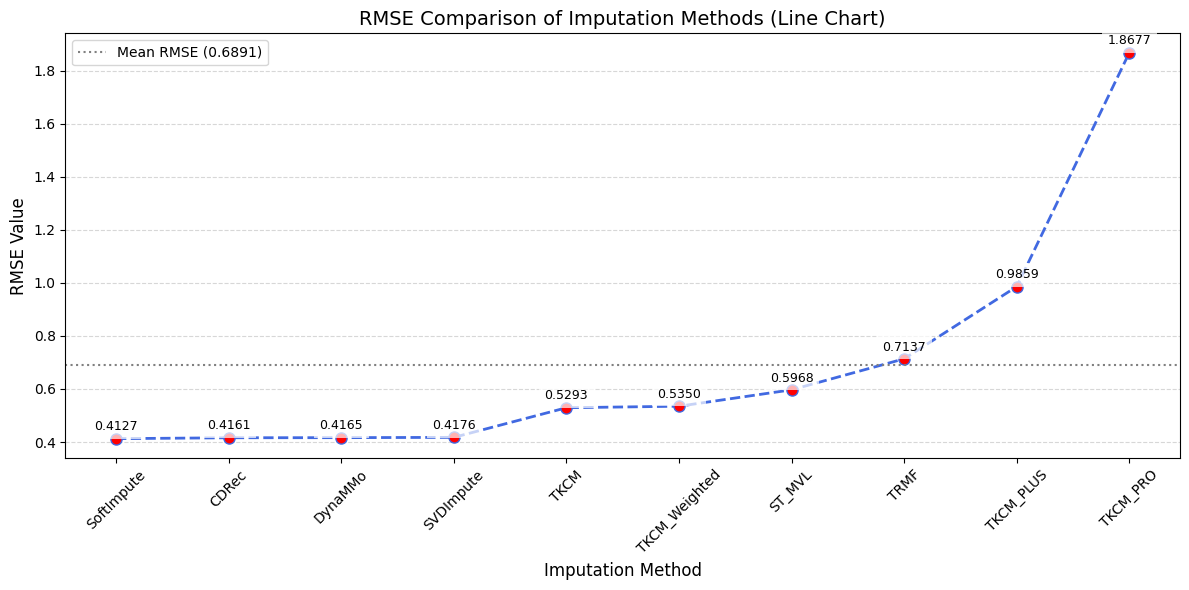

In [45]:
# Line chart implementation
plt.figure(figsize=(12, 6))

# Create line plot with markers
line = plt.plot(results_sorted["Method"], 
                results_sorted["RMSE"], 
                marker='o', 
                markersize=8,
                linestyle='--',
                color='royalblue',
                linewidth=2,
                markerfacecolor='red')

# Annotate each point with RMSE value
for x, y in zip(range(len(results_sorted)), results_sorted["RMSE"]):
    plt.text(x, y+0.02, f"{y:.4f}", 
             ha='center', 
             va='bottom',
             fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Add reference line for visual comparison
plt.axhline(y=results_sorted["RMSE"].mean(), 
            color='gray', 
            linestyle=':', 
            label=f'Mean RMSE ({results_sorted["RMSE"].mean():.4f})')

# Chart formatting
plt.title("RMSE Comparison of Imputation Methods (Line Chart)", fontsize=14)
plt.xlabel("Imputation Method", fontsize=12)
plt.ylabel("RMSE Value", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend()

# Ensure proper layout
plt.tight_layout()
plt.show()

### Simulating a dataset similar to the context of my imputation results

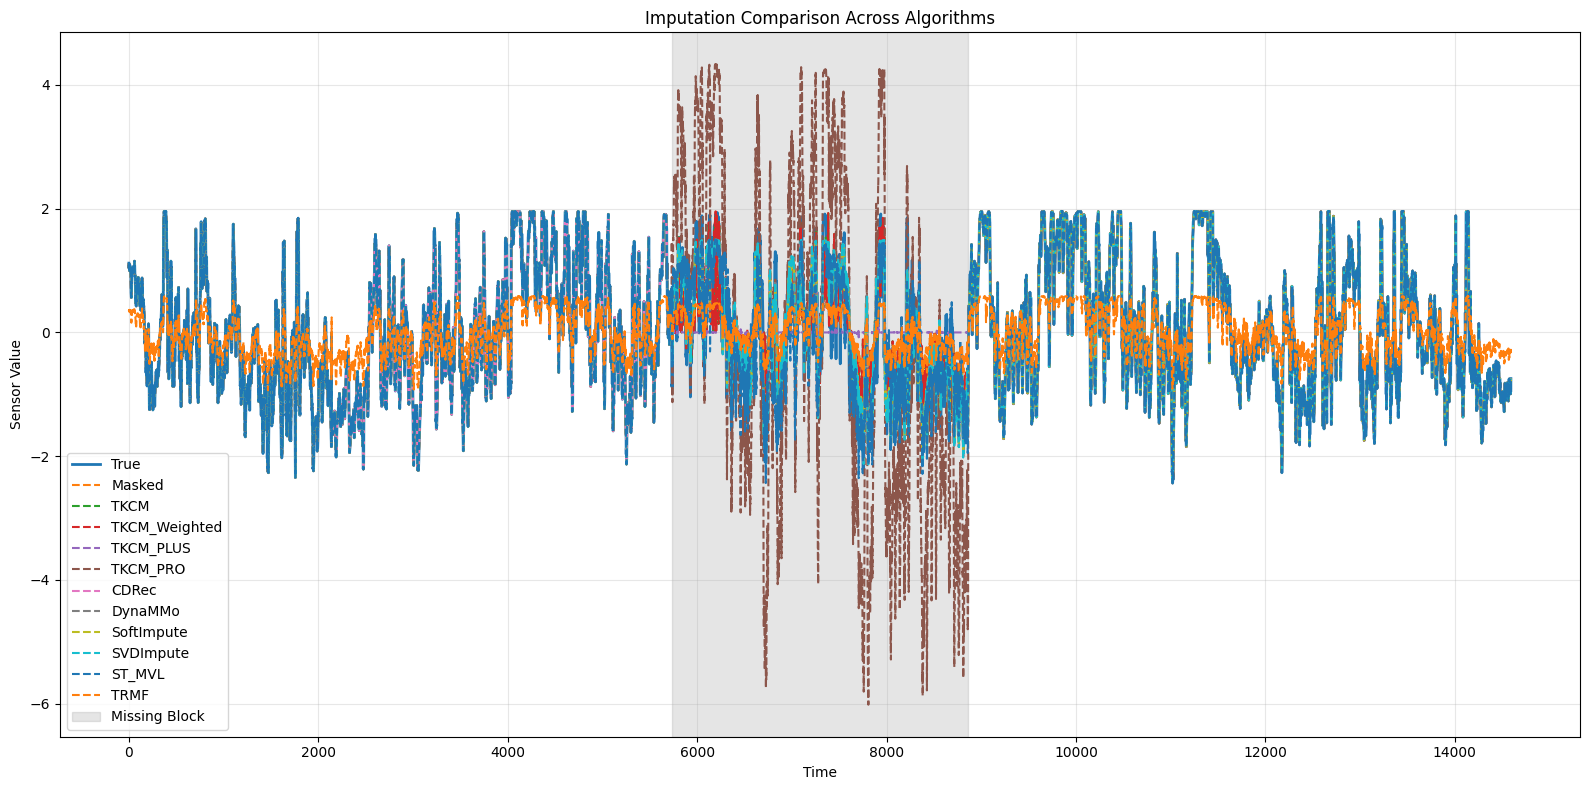

In [46]:
# --- Build dict from your computed arrays ---
imputed_data = {
    "True":           true_target_array,
    "Masked":         masked_target_array,
    "TKCM":           tkcm_imputed,
    "TKCM_Weighted":  tkcm_weighted_imputed,
    "TKCM_PLUS":      tkcm_plus_imputed,
    "TKCM_PRO":       tkcm_pro_imputed,
    "CDRec":          cdrec_imputed,
    "DynaMMo":        dynammo_imputed,
    "SoftImpute":     soft_imputed,
    "SVDImpute":      svd_imputed,
    "ST_MVL":         st_mvl_imputed,
    "TRMF":           trmf_imputed,
}

# --- Time axis & missing block from your indices ---
time = np.arange(len(true_target_array))

plt.figure(figsize=(16, 8))
for method, series in imputed_data.items():
    linestyle = "-" if method == "True" else "--"
    linewidth = 2 if method == "True" else 1.5
    plt.plot(time, np.asarray(series), label=method, linestyle=linestyle, linewidth=linewidth)

# highlight your missing block
plt.axvspan(start_idx, end_idx, color="gray", alpha=0.2, label="Missing Block")

plt.title("Imputation Comparison Across Algorithms")
plt.xlabel("Time")
plt.ylabel("Sensor Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


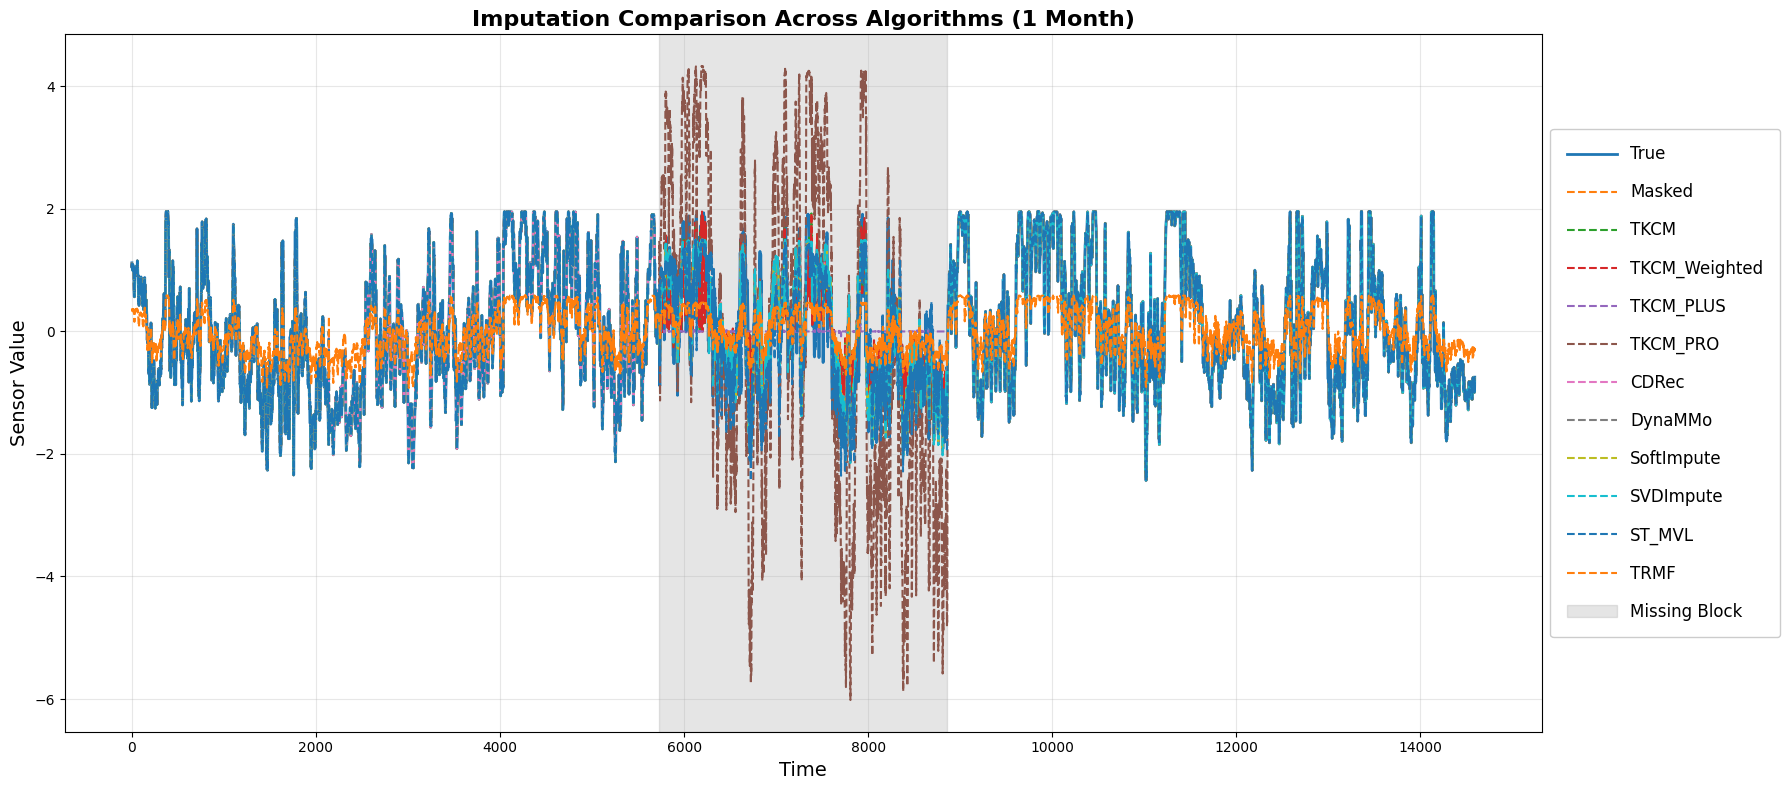

In [47]:


# Create the plot
fig, ax = plt.subplots(figsize=(18, 8))  # wider for clarity

for method, series in imputed_data.items():
    linestyle = "-" if method == "True" else "--"
    linewidth = 2 if method == "True" else 1.5
    ax.plot(time, np.asarray(series), label=method, linestyle=linestyle, linewidth=linewidth)

# Highlight missing block
ax.axvspan(start_idx, end_idx, color="gray", alpha=0.2, label="Missing Block")

# Titles & labels
ax.set_title("Imputation Comparison Across Algorithms (1 Month)", fontsize=16, fontweight="bold")
ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Sensor Value", fontsize=14)
ax.grid(True, alpha=0.3)

# Legend improvements
legend = ax.legend(
    loc="center left",          # move to left outside plot
    bbox_to_anchor=(1, 0.5),    # place outside to avoid overlap
    fontsize=12,                # bigger text
    frameon=True,               # solid frame
    facecolor="white",          # white background
    framealpha=1,               # no transparency
    borderpad=1,                # padding inside frame
    labelspacing=1.2,           # vertical spacing between labels
    handlelength=3              # longer line samples
)

fig.tight_layout()

# Save before showing
fig.savefig("plots/middle_block_comparison_1month.pdf", bbox_inches="tight")
fig.savefig("plots/middle_block_comparison_1month.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)


### 1) Single overlay (True + Masked + all methods) — zoomed to missing block

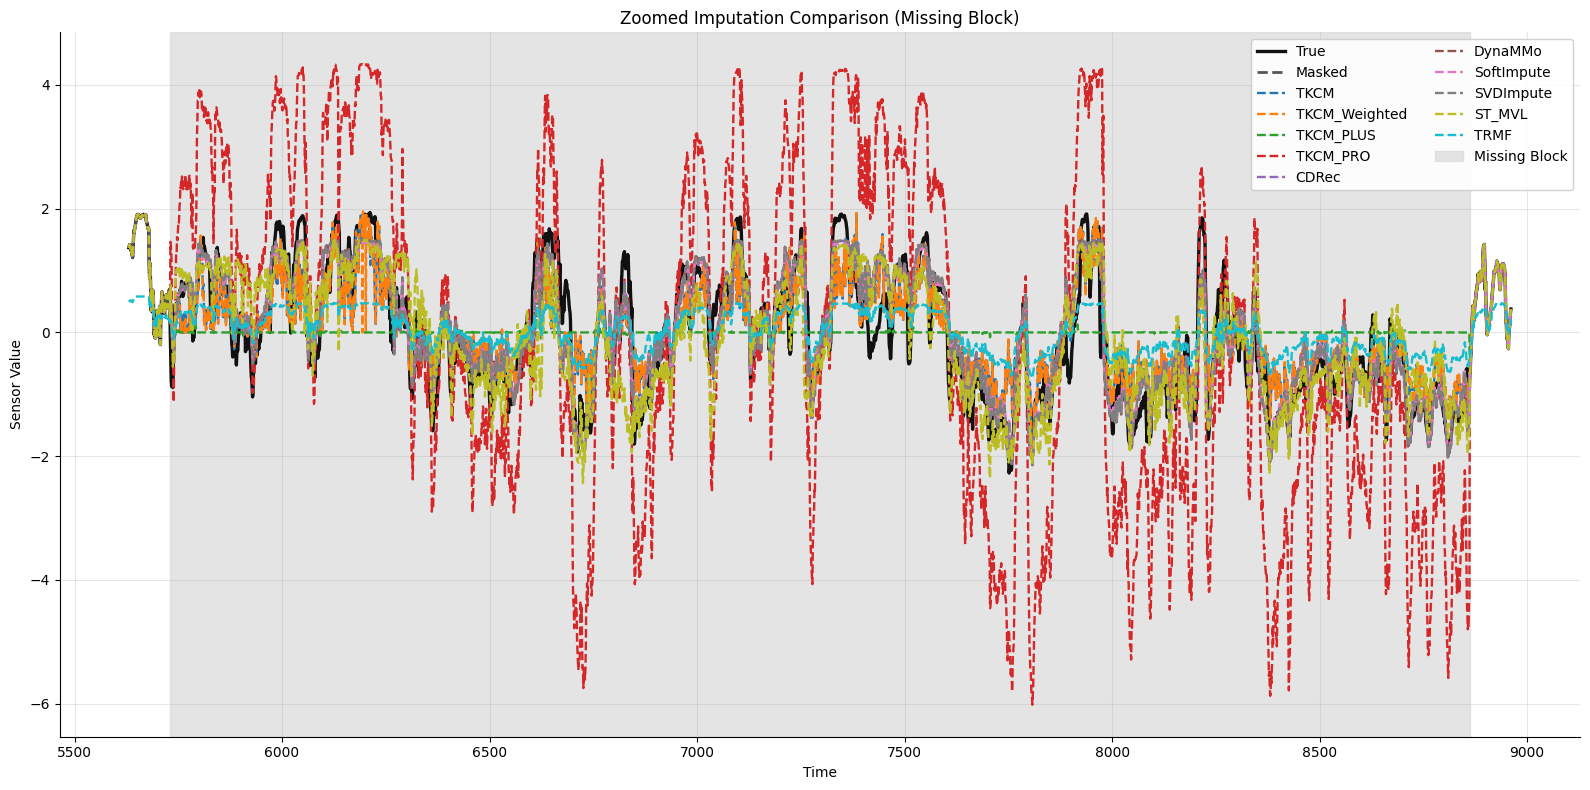

In [50]:

def plot_zoom_block_overlay(true_target_array,
                            masked_target_array,
                            start_idx, end_idx,
                            series_map,
                            pad=50,
                            out_base="plots/zoom_block_overlay"):
    """
    Zooms into the missing block [start_idx:end_idx] with optional 'pad' context.
    series_map: {"MethodName": imputed_array, ...}  (do NOT include True/Masked)
    Saves out_base.pdf/.png
    """
    # window
    n = len(true_target_array)
    i0 = max(0, start_idx - pad)
    i1 = min(n, end_idx + pad)
    t = np.arange(i0, i1)

    # ensure folder
    os.makedirs(os.path.dirname(out_base), exist_ok=True)

    # style
    fig, ax = plt.subplots(figsize=(16, 8))
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.grid(True, alpha=0.3)

    # main series
    ax.plot(t, np.asarray(true_target_array)[i0:i1], label="True", color="#111111", linewidth=2.4)
    ax.plot(t, np.asarray(masked_target_array)[i0:i1], "--", label="Masked", color="#555555", linewidth=2.0)

    # palette (hex-safe)
    palette = [
        "#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
        "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf",
        "#aec7e8","#ffbb78"
    ]

    # plot imputations
    for i, (name, arr) in enumerate(series_map.items()):
        arr = np.asarray(arr)
        ax.plot(t, arr[i0:i1], linestyle="--", linewidth=1.7, color=palette[i % len(palette)], label=name)

    # highlight missing block
    ax.axvspan(start_idx, end_idx, color="0.85", alpha=0.7, label="Missing Block")

    ax.set_title("Zoomed Imputation Comparison (Missing Block)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Sensor Value")
    ax.legend(loc="best", ncol=2, frameon=True, framealpha=0.9)
    fig.tight_layout()

    # save
    fig.savefig(f"{out_base}.pdf", bbox_inches="tight")
    fig.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ----- USE IT -----
series_map = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
    #"Zero": zero_imputed,
    #"Min": min_imputed,
    #"Interpolation": interp_imputed,
}

plot_zoom_block_overlay(true_target_array, masked_target_array, start_idx, end_idx,
                        series_map, pad=100,
                        out_base="plots/valley_middle_block_overlay_1month")


### 2) Grid of overlays (each subplot = True vs one method) — zoomed to missing block

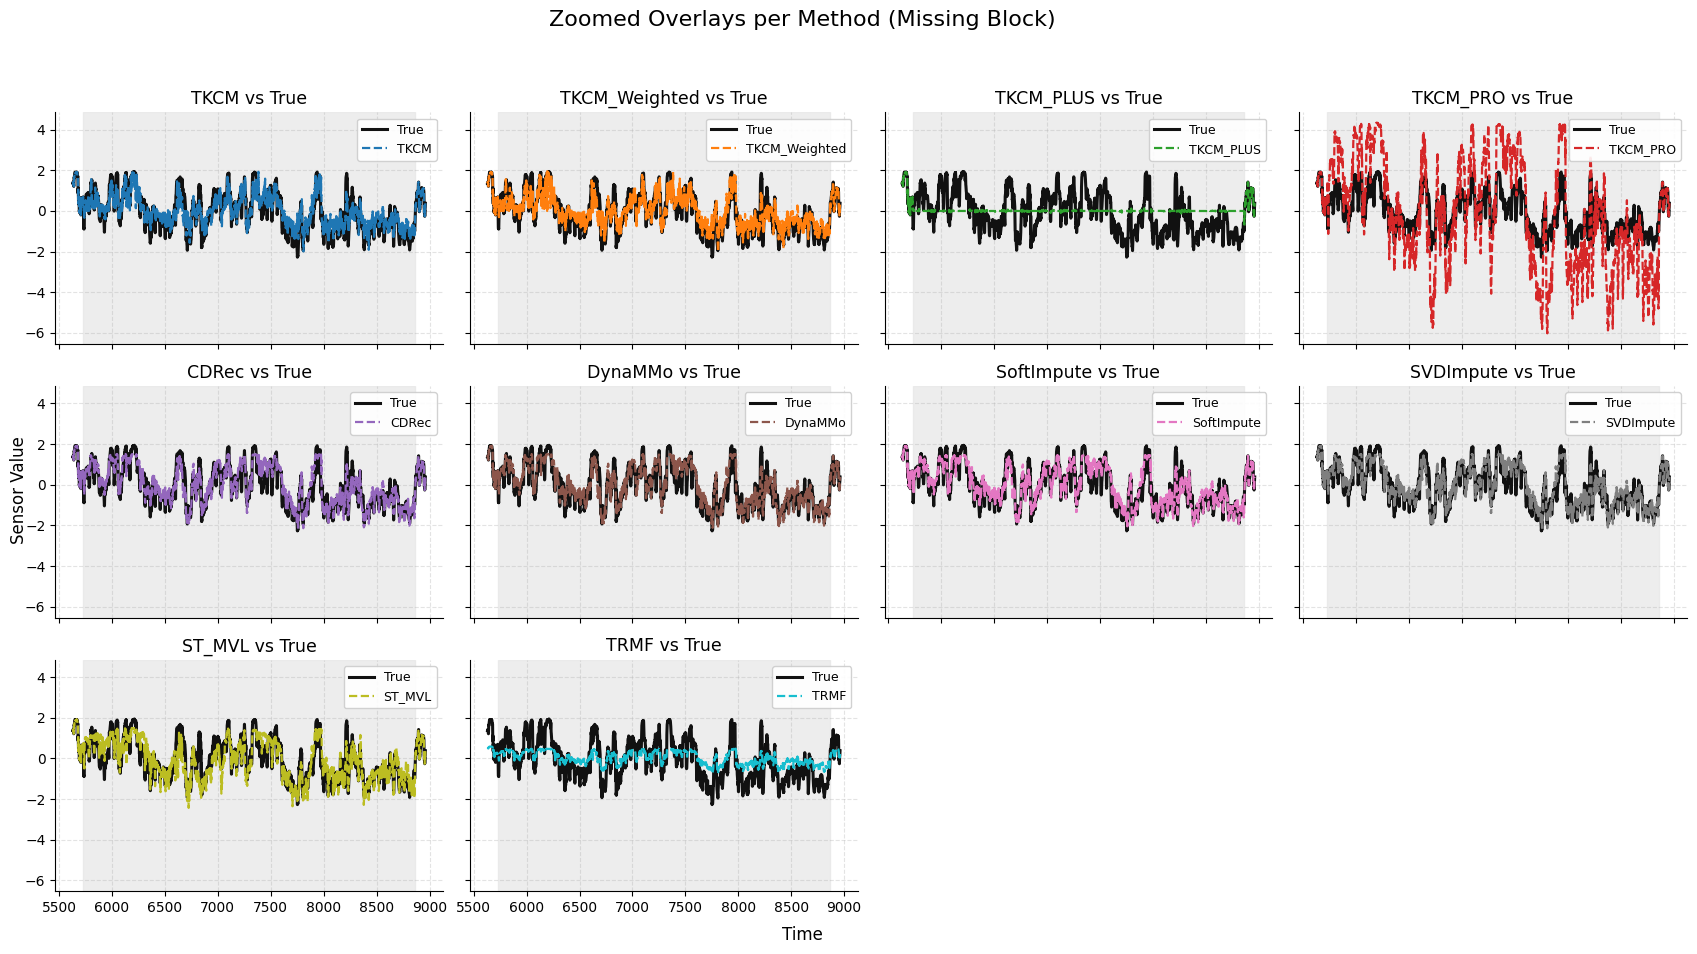

In [51]:

def plot_zoom_block_grid(true_target_array,
                         start_idx, end_idx,
                         series_map,
                         rows=3, cols=4,
                         pad=50,
                         out_base="plots/valley_middle_block_grid"):
    """
    Grid of True vs each method over the missing block [+/- pad].
    series_map: {"MethodName": imputed_array, ...}
    Saves out_base.pdf/.png
    """
    n = len(true_target_array)
    i0 = max(0, start_idx - pad)
    i1 = min(n, end_idx + pad)
    t = np.arange(i0, i1)
    true_block = np.asarray(true_target_array)[i0:i1]

    os.makedirs(os.path.dirname(out_base), exist_ok=True)

    methods = list(series_map.keys())[:rows*cols]
    palette = [
        "#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
        "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf",
        "#aec7e8","#ffbb78"
    ]

    fig, axes = plt.subplots(rows, cols, figsize=(18, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, method in enumerate(methods):
        ax = axes[i]
        for s in ("top", "right"): ax.spines[s].set_visible(False)
        ax.grid(True, linestyle="--", alpha=0.35)

        ax.plot(t, true_block, color="#111111", linewidth=2.2, label="True")
        imputed_block = np.asarray(series_map[method])[i0:i1]
        ax.plot(t, imputed_block, "--", linewidth=1.6, color=palette[i % len(palette)], label=method)

        # shade exact missing span
        ax.axvspan(start_idx, end_idx, color="0.9", alpha=0.7)
        ax.set_title(f"{method} vs True", fontsize=12.5)
        ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.9)

    # remove unused panels
    for j in range(len(methods), rows*cols):
        fig.delaxes(axes[j])

    fig.suptitle("Zoomed Overlays per Method (Missing Block)", fontsize=16, y=0.98)
    fig.text(0.5, 0.05, "Time", ha="center", fontsize=12)
    fig.text(0.06, 0.5, "Sensor Value", va="center", rotation="vertical", fontsize=12)
    fig.tight_layout(rect=[0.06, 0.06, 1, 0.95])

    fig.savefig(f"{out_base}.pdf", bbox_inches="tight")
    fig.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ----- USE IT -----
plot_zoom_block_grid(true_target_array, start_idx, end_idx, series_map,
                     rows=3, cols=4, pad=100,
                     out_base="plots/valley_middle_block_overlays_1month")
